# 05 — Centrality, communities, and hypothesis test

Loads the saved repo network and runs the core DMA analyses:
- Centrality measures (degree, betweenness, eigenvector)
- Community detection (Louvain algorithm — modularity optimization)
- Language-community association test (chi-squared)
- Assortativity by language
- Final visualization for the slide deck

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import chi2_contingency

In [2]:
G = nx.read_graphml("../data/processed/repo_network.graphml")
repos_df = pd.read_csv("../data/processed/repos_clean.csv")

print(f"Loaded graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Repos DataFrame: {repos_df.shape}")

Loaded graph: 412 nodes, 8960 edges
Repos DataFrame: (500, 14)


In [3]:
# centrality measures
deg_cent = nx.degree_centrality(G)
between = nx.betweenness_centrality(G, k=100, seed=42)  # k for speed
eigen = nx.eigenvector_centrality(G, max_iter=1000)

def top_n(d, n=10):
    return sorted(d.items(), key=lambda x: -x[1])[:n]

print("Top 10 by DEGREE centrality (most shared contributors):")
for name, val in top_n(deg_cent):
    print(f"  {val:.4f}  {name}")

print("\nTop 10 by BETWEENNESS centrality (network bridges):")
for name, val in top_n(between):
    print(f"  {val:.4f}  {name}")

print("\nTop 10 by EIGENVECTOR centrality (connected to important repos):")
for name, val in top_n(eigen):
    print(f"  {val:.4f}  {name}")

Top 10 by DEGREE centrality (most shared contributors):
  0.4015  gradio-app/gradio
  0.3552  kyegomez/swarms
  0.3528  bee-san/Ciphey
  0.3504  bitsandbytes-foundation/bitsandbytes
  0.3479  pathwaycom/llm-app
  0.3479  microsoft/LoRA
  0.3479  2FastLabs/agent-squad
  0.3406  vercel/ai
  0.3382  yamadashy/repomix
  0.3358  gorse-io/gorse

Top 10 by BETWEENNESS centrality (network bridges):
  0.0551  scikit-learn-contrib/imbalanced-learn
  0.0482  gradio-app/gradio
  0.0412  CMU-Perceptual-Computing-Lab/openpose
  0.0392  amusi/awesome-object-detection
  0.0379  bitsandbytes-foundation/bitsandbytes
  0.0367  ageitgey/face_recognition
  0.0323  huggingface/transformers
  0.0312  flwrlabs/flower
  0.0310  ZuzooVn/machine-learning-for-software-engineers
  0.0305  EthicalML/awesome-production-machine-learning

Top 10 by EIGENVECTOR centrality (connected to important repos):
  0.0939  gradio-app/gradio
  0.0930  vercel/ai
  0.0929  bee-san/Ciphey
  0.0929  gorse-io/gorse
  0.0928  py-why/do

In [4]:
# community detection via Louvain (modularity optimization family — same as fast greedy from course)
communities = nx.community.louvain_communities(G, seed=42)
modularity = nx.community.modularity(G, communities)

print(f"Detected {len(communities)} communities")
print(f"Modularity: {modularity:.4f}")
print(f"\nCommunity sizes (top 10):")
sizes = sorted([len(c) for c in communities], reverse=True)
for i, s in enumerate(sizes[:10]):
    print(f"  Community {i}: {s} repos")

Detected 11 communities
Modularity: 0.2092

Community sizes (top 10):
  Community 0: 148 repos
  Community 1: 99 repos
  Community 2: 54 repos
  Community 3: 41 repos
  Community 4: 24 repos
  Community 5: 19 repos
  Community 6: 15 repos
  Community 7: 4 repos
  Community 8: 3 repos
  Community 9: 3 repos


In [5]:
# map each node to its community
node_community = {}
for i, comm in enumerate(communities):
    for n in comm:
        node_community[n] = i

# attach to repos DataFrame
df = repos_df.set_index("full_name")
df_g = df.loc[df.index.intersection(G.nodes())].copy()
df_g["community"] = df_g.index.map(node_community)

print(f"Repos in graph + dataframe: {len(df_g)}")

Repos in graph + dataframe: 412


In [6]:
# characterize each large community by dominant languages and example repos
print("Community summaries (≥ 10 repos):")
for i in sorted(df_g["community"].unique()):
    sub = df_g[df_g["community"] == i]
    if len(sub) < 10:
        continue
    top_langs = sub["language"].value_counts().head(3)
    top_repos = sub.nlargest(5, "stars").index.tolist()
    print(f"\n--- Community {i} ({len(sub)} repos) ---")
    print("  Top languages:")
    for lang, count in top_langs.items():
        print(f"    {lang}: {count}")
    print("  Top repos by stars:")
    for r in top_repos:
        print(f"    {r}")

Community summaries (≥ 10 repos):

--- Community 0 (148 repos) ---
  Top languages:
    Python: 79
    Jupyter Notebook: 21
    C++: 14
  Top repos by stars:
    tensorflow/tensorflow
    huggingface/transformers
    pytorch/pytorch
    opencv/opencv
    d2l-ai/d2l-zh

--- Community 2 (41 repos) ---
  Top languages:
    Python: 16
    TypeScript: 7
    Go: 4
  Top repos by stars:
    thedotmack/claude-mem
    FlowiseAI/Flowise
    streamlit/streamlit
    paperless-ngx/paperless-ngx
    hpcaitech/ColossalAI

--- Community 3 (24 repos) ---
  Top languages:
    Python: 20
    Jupyter Notebook: 2
    Rust: 1
  Top repos by stars:
    ultralytics/ultralytics
    ultralytics/yolov5
    roboflow/supervision
    babysor/MockingBird
    patchy631/ai-engineering-hub

--- Community 4 (19 repos) ---
  Top languages:
    Python: 7
    Jupyter Notebook: 4
    HTML: 2
  Top repos by stars:
    f/prompts.chat
    microsoft/ML-For-Beginners
    microsoft/AI-For-Beginners
    e2b-dev/awesome-ai-agents
 

In [7]:
# Chi-squared test: is language independent of community membership?
# filter to ensure expected counts >= 5 (course requirement)
top_langs = df_g["language"].value_counts().head(5).index
big_communities = df_g["community"].value_counts()
big_communities = big_communities[big_communities >= 15].index

filt = df_g[df_g["language"].isin(top_langs) & df_g["community"].isin(big_communities)]
ct = pd.crosstab(filt["language"], filt["community"])
print("Contingency table (language x community):")
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)
print(f"\nChi-squared statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6g}")
print(f"\nMinimum expected count: {expected.min():.2f}  (must be >= 5)")
print(f"Interpretation: {'reject H0 — language IS associated with community' if p < 0.05 else 'fail to reject H0 — no significant association'}")

Contingency table (language x community):
community         0   2   3   4   5   7   10
language                                    
C++               14   4   0   2   0  13   1
JavaScript         1   2   0   0   2   5   0
Jupyter Notebook  21   0   2   4   8   9   7
Python            79  16  20   7  27  48   1
TypeScript         1   7   0   0   1   8   0

Chi-squared statistic: 82.53
Degrees of freedom: 24
p-value: 2.3974e-08

Minimum expected count: 0.29  (must be >= 5)
Interpretation: reject H0 — language IS associated with community


In [8]:
# assortativity by language — do repos in the same language tend to connect?
node_lang = {}
for n in G.nodes():
    if n in df.index:
        lang = df.at[n, "language"]
        node_lang[n] = str(lang) if pd.notna(lang) else "Unknown"
    else:
        node_lang[n] = "Unknown"

nx.set_node_attributes(G, node_lang, "language")
assort_lang = nx.attribute_assortativity_coefficient(G, "language")
print(f"Assortativity by language: {assort_lang:.4f}")
print("(positive = language-homophily, negative = anti-homophily, 0 = neutral)")

Assortativity by language: 0.0268
(positive = language-homophily, negative = anti-homophily, 0 = neutral)


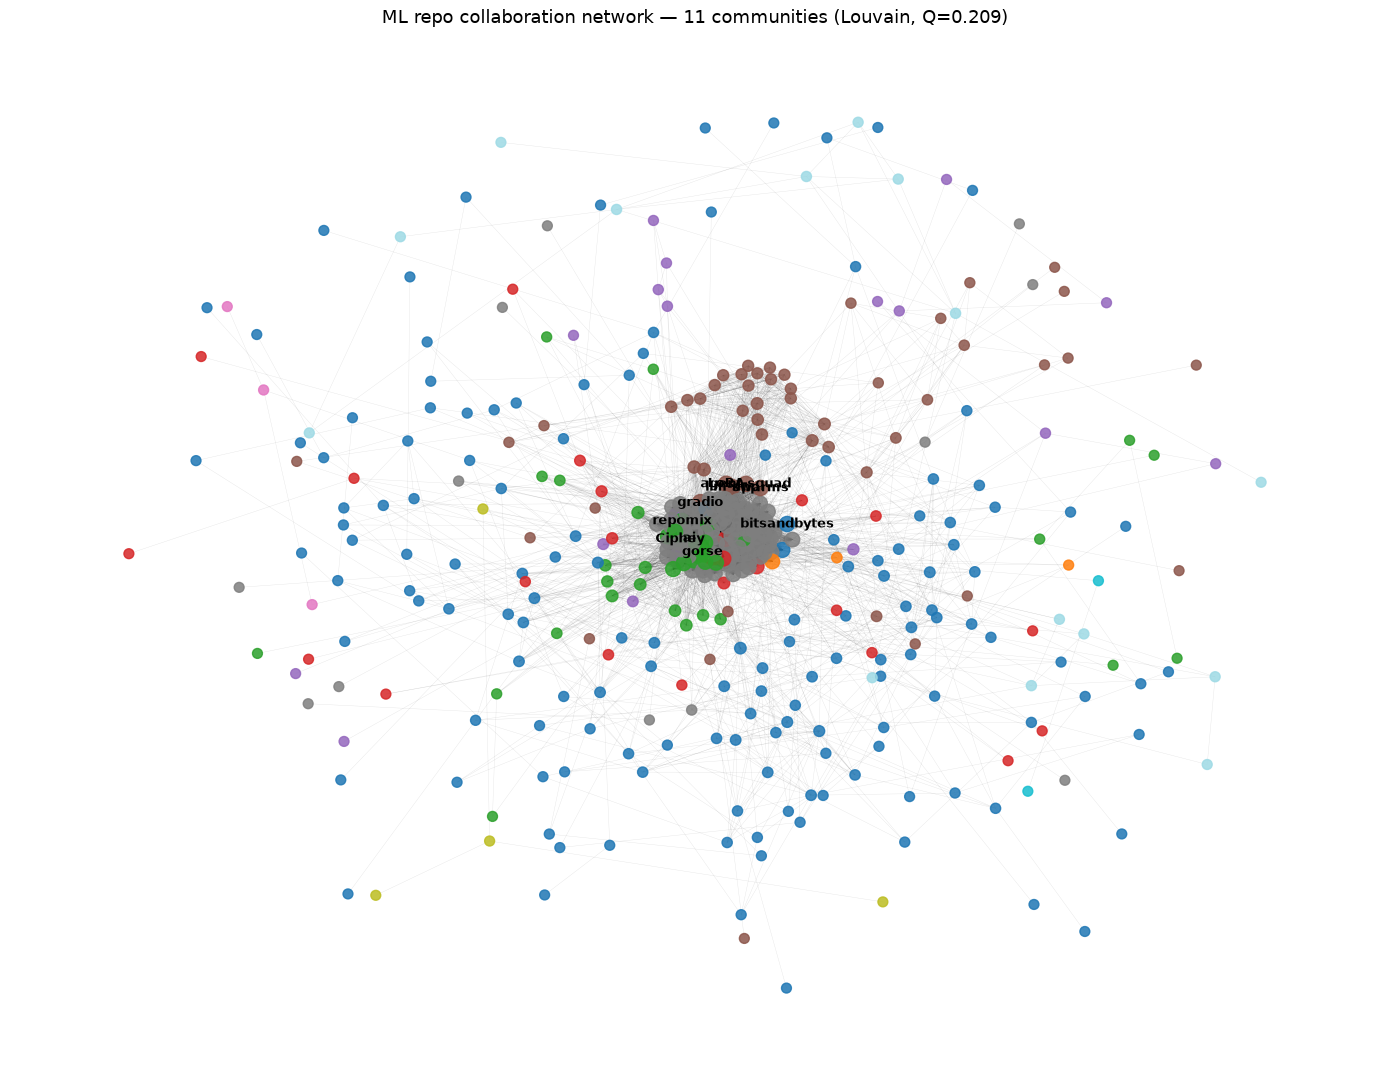

Saved plots/network_communities.png


In [9]:
# final visualization — network colored by community
plt.figure(figsize=(14, 11))
pos = nx.spring_layout(G, seed=42, k=0.3, iterations=50)

colors = [node_community.get(n, -1) for n in G.nodes()]
sizes = [50 + 200 * deg_cent[n] for n in G.nodes()]

nx.draw_networkx_edges(G, pos, alpha=0.1, width=0.3)
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=colors, cmap="tab20", alpha=0.85)

# label only the top 10 most central repos
top_central = set(n for n, _ in top_n(deg_cent, 10))
labels = {n: n.split("/")[-1] for n in top_central}
nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight="bold")

plt.title(f"ML repo collaboration network — {len(communities)} communities (Louvain, Q={modularity:.3f})",
          fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig("../plots/network_communities.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved plots/network_communities.png")

In [10]:
# save analysis outputs for slide prep
results = {
    "n_nodes": G.number_of_nodes(),
    "n_edges": G.number_of_edges(),
    "n_communities": len(communities),
    "modularity": float(modularity),
    "chi2_stat": float(chi2),
    "chi2_p": float(p),
    "chi2_dof": int(dof),
    "assortativity_language": float(assort_lang),
    "top_degree": [(n, float(v)) for n, v in top_n(deg_cent, 10)],
    "top_betweenness": [(n, float(v)) for n, v in top_n(between, 10)],
    "top_eigenvector": [(n, float(v)) for n, v in top_n(eigen, 10)],
}

import json
with open("../data/processed/analysis_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("Saved analysis_results.json")

Saved analysis_results.json


In [11]:
# Tightened chi-squared: keep only top 3 languages and communities with >= 30 repos
# to ensure all expected counts >= 5 (course requirement)
top_langs_tight = ["Python", "Jupyter Notebook", "C++"]
big_communities_tight = df_g["community"].value_counts()
big_communities_tight = big_communities_tight[big_communities_tight >= 30].index

filt_tight = df_g[df_g["language"].isin(top_langs_tight) & df_g["community"].isin(big_communities_tight)]
ct_tight = pd.crosstab(filt_tight["language"], filt_tight["community"])
print("Tightened contingency table:")
print(ct_tight)

chi2_t, p_t, dof_t, expected_t = chi2_contingency(ct_tight)
print(f"\nChi-squared: {chi2_t:.2f}, df: {dof_t}, p: {p_t:.4g}")
print(f"Minimum expected count: {expected_t.min():.2f}  (now >= 5)")
print(f"Interpretation: {'reject H0 — language IS associated with community' if p_t < 0.05 else 'fail to reject H0'}") 

Tightened contingency table:
community          0   2   5   7
language                        
C++               14   4   0  13
Jupyter Notebook  21   0   8   9
Python            79  16  27  48

Chi-squared: 12.66, df: 6, p: 0.04872
Minimum expected count: 2.59  (now >= 5)
Interpretation: reject H0 — language IS associated with community


Pearson:  r = 0.0916,  p = 0.06319,  N = 412
Spearman: r = 0.1629,  p = 0.0009034


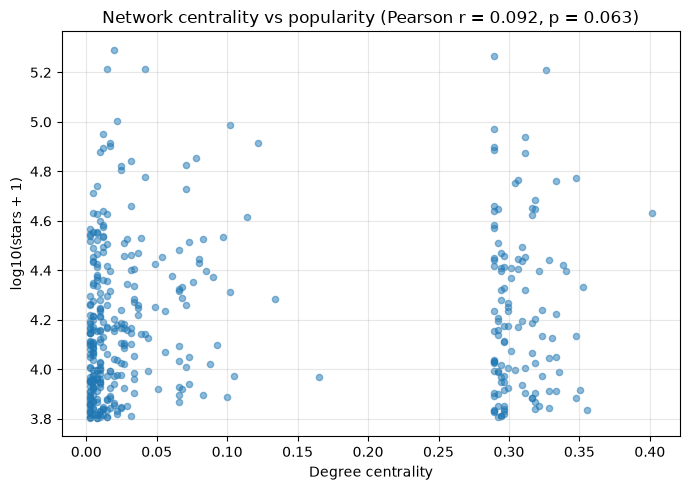

In [12]:
# Headline statistical test: correlation between network centrality and popularity
from scipy.stats import pearsonr, spearmanr

df_test = df_g.copy()
df_test["deg_centrality"] = df_test.index.map(deg_cent)
df_test["log_stars"] = np.log10(df_test["stars"] + 1)
df_test = df_test.dropna(subset=["deg_centrality", "log_stars"])

r_p, p_p = pearsonr(df_test["deg_centrality"], df_test["log_stars"])
print(f"Pearson:  r = {r_p:.4f},  p = {p_p:.4g},  N = {len(df_test)}")

r_s, p_s = spearmanr(df_test["deg_centrality"], df_test["log_stars"])
print(f"Spearman: r = {r_s:.4f},  p = {p_s:.4g}")

# scatter plot for the slide
plt.figure(figsize=(7, 5))
plt.scatter(df_test["deg_centrality"], df_test["log_stars"], alpha=0.5, s=20)
plt.xlabel("Degree centrality")
plt.ylabel("log10(stars + 1)")
plt.title(f"Network centrality vs popularity (Pearson r = {r_p:.3f}, p = {p_p:.2g})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/centrality_vs_stars.png", dpi=150, bbox_inches="tight")
plt.show() 